# Module 02: A Box Model of Land-Atmosphere Carbon Balance

### 1. Introduction


Mass 1 is land
Mass 2 is atmosphere
k12 is turnover from land to atmosphere
k21 is turnover from atmosphere to land

20 years with single year time steps

populate units! figure out axes!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

M1i = 1100.0 #initial land mass carbon
M2i = 300.0 #initial atmosphere mass carbon

k12 = 0.075 #land to atmosphere flux
k21 = 0.1 #atmosphere to land flux

ti = 0.0 #initial time
tf = 20.0 #length of time
dt = 1 #step of time


In [ ]:
t = np.arange(ti,tf+dt,dt) 

Nt = t.size #nt is vector that we can now use to set the length of the rest of our dataframes for the toy model

print('t has '+str(Nt)+' time steps')

t has 21 time steps


In [ ]:
M1 = np.zeros((Nt,)) #land mass carbon empty dataframe so we can start storing M1[t] values
M2 = np.zeros((Nt,)) #land mass carbon empty dataframe so we can start storing M1[t] values

In [ ]:
#initialize the model from t = 0 to t = 20


for i in np.arange(Nt):
    if (i==0): #at 0 time, use our initial conditions

        M1[i] = M1i
        M2[i] = M2i
        
    else: #if not 0 time, we need to evaluate the in and out flux for each bucket
        dM1dt = k21*M2[i-1] - k12*M1[i-1] #land flux (atmosphere deposition/photosynthesis minus fire/respiration) -> total flux for period t-1
        dM2dt = k12*M1[i-1] - k21*M2[i-1] #atmosphere flux (fire/respiration input minus deposition/photosynthesis output) from previous year)
        
        M1[i] = M1[i-1] + dM1dt*dt #previous condition plus total flux = mass carbon at Nt(i)
        M2[i] = M2[i-1] + dM2dt*dt


In [ ]:
#analytical solution to the model!
M1_anlt = (k21*(M1i+M2i))/(k12+k21) + (k12*M1i - k21*M2i)/(k12+k21)*np.exp(-(k12+k21)*t)
M2_anlt = (k12*(M1i+M2i))/(k12+k21) - (k12*M1i - k21*M2i)/(k12+k21)*np.exp(-(k12+k21)*t)

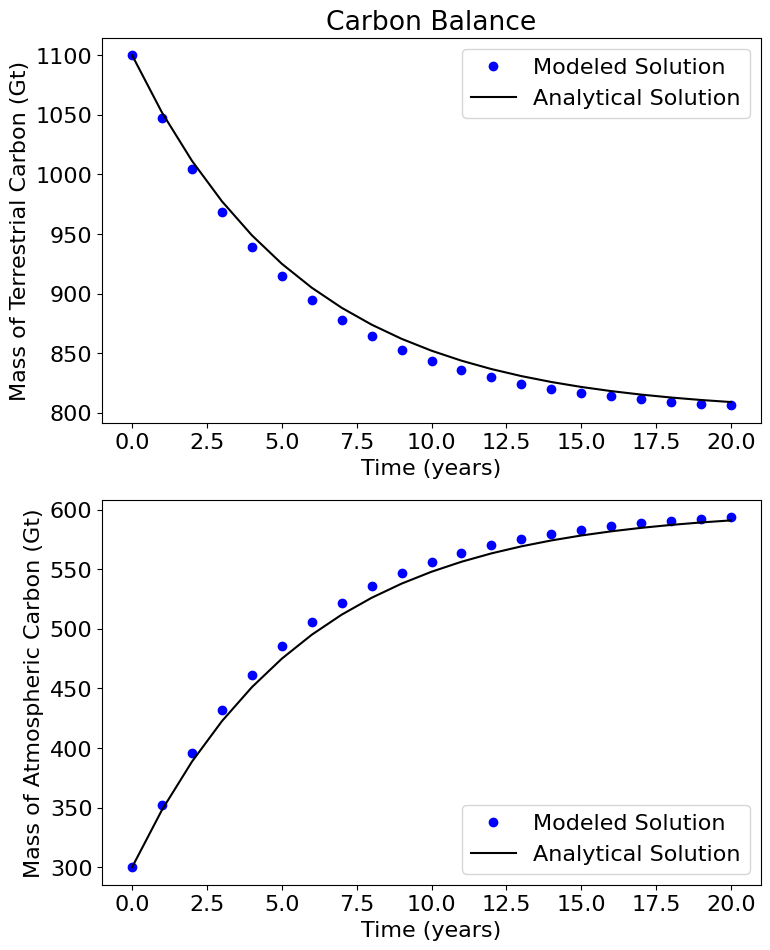

In [7]:
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Carbon Balance')
plt.plot(t,M1,'bo', label='Modeled Solution')
plt.plot(t,M1_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Mass of Terrestrial Carbon (Gt)')
plt.legend()

plt.subplot(2,1,2)
plt.plot(t,M2,'bo', label='Modeled Solution')
plt.plot(t,M2_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Mass of Atmospheric Carbon (Gt)')
plt.legend()

plt.show()